In [7]:
import numpy as np
import matplotlib.pyplot as plt

## FUNCTION DEFINITIONS

In [13]:
#Generates spins from spins.txt
def loadData():
    data = np.genfromtxt("spins.txt", dtype=int, delimiter=1)
    spinsAngle = data * np.pi
    L = spinsAngle.shape[0]
    return spinsAngle, L

In [14]:
#the avg x-compoennt of Spin Angle
def magnetization(spinsAngle):
    return np.mean(np.cos(spinsAngle))

In [15]:
#the delta Energy of changing one of the node in the lattice
def delE(i,j,J,D,H,newAngle):
    
    #Applying Periodic Boundary Conditions
    if i==0:
        up=L-1
    else:
        up=i-1
    if i==L-1:
        down = 0
    else:
        down = i+1
    if j==0:
        left=L-1
    else:
        left=j-1
    if j==L-1:
        right = 0
    else:
        right = j+1
        
    oldAngle = spinsAngle[i,j]
    
    #Finding Energy old
    Eold = -J*(
        np.cos(oldAngle-spinsAngle[up, j]) +
        np.cos(oldAngle-spinsAngle[down, j]) +
        np.cos(oldAngle-spinsAngle[i, left]) +
        np.cos(oldAngle-spinsAngle[i, right]))-(D*np.cos(oldAngle)**2)-H*np.cos(oldAngle)
       
    #Energy of proposed newAngle
    Enew = -J*(
        np.cos(newAngle-spinsAngle[up, j]) +
        np.cos(newAngle-spinsAngle[down, j]) +
        np.cos(newAngle-spinsAngle[i, left]) +
        np.cos(newAngle-spinsAngle[i, right]))-(D*np.cos(newAngle)**2)-H*np.cos(newAngle)

    delE = Enew - Eold
    return delE

In [16]:
#Does L*L random checks and determines whether the Spin can change using 
rng = np.random.default_rng()
def sweep(J,D,H,T):
    #The maximum spin rotation change allowd
    deltaTheta = np.pi
    
    for x in range(L * L):
        i = rng.integers(0, L)
        j = rng.integers(0, L)
        
        oldAngle = spinsAngle[i,j]
        newAngle = oldAngle + rng.uniform(-deltaTheta, deltaTheta)
        newAngle = newAngle % (2*np.pi)
        dE = delE(i,j,J,D,H,newAngle)
        
        if dE<= 0:
            spinsAngle[i,j] = newAngle
        elif T>0:
            P = (np.e)**(-dE/T)
            if rng.random() <= P:
                spinsAngle[i,j] = newAngle          

## Color Gradient of Spin Angles in Lattice

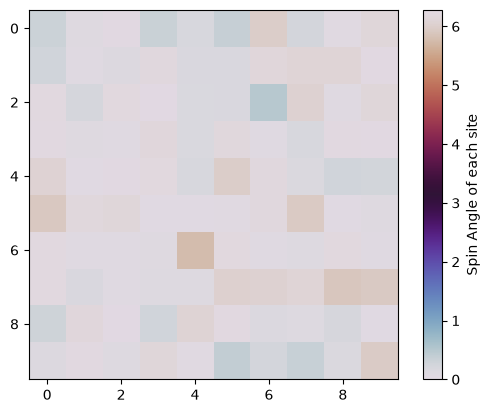

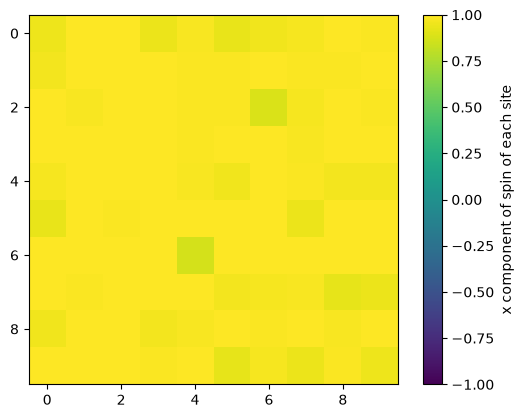

In [25]:
spinsAngle,L = loadData()
J = 1.0 #Coupling Strength J 
T = 10 #Temperature
D = 100 #Anisotropy Term
H = 100 #Magnetic Field Strength H 

#Monte Carlo of 10 sweeps
for x in range(0,1000):
    sweep(J,D,H,T)

plt.imshow(spinsAngle, vmin=0, vmax=2*np.pi,  cmap="twilight")
plt.colorbar(label="Spin Angle of each site")
plt.show()

plt.imshow(np.cos(spinsAngle), vmin=-1, vmax=1)
plt.colorbar(label="x component of spin of each site")

## Hysteresis Simulation

In [18]:
def findCoerciveField(HValues, MValues):
    for i in range(len(MValues) - 1):
        if MValues[i] == 0:
            return HValues[i]
        if MValues[i]*MValues[i + 1] < 0:
            H1 = HValues[i]
            H2 = HValues[i + 1]
            M1 = MValues[i]
            M2 = MValues[i + 1]
            Hc = H1+(-M1)*(H2-H1)/(M2-M1)
            return Hc
    return None

In [19]:
#Monte Carlo Sweep for each H, changing by dH each run
def Hysteresis(J,D,T,Hmax,dH,amt):
    MDownValues = []
    HDownValues = []
    MUPValues = []
    HUPValues = []
    H = Hmax
    while H>=-Hmax:
        for x in range(0,amt):
            sweep(J,D,H,T)
        MDownValues.append(magnetization(spinsAngle))
        HDownValues.append(H)
        H -= dH

    H = -Hmax   
    while H<=Hmax:
        for x in range(0,amt):
            sweep(J,D,H,T)
        MUPValues.append(magnetization(spinsAngle))
        HUPValues.append(H)
        H += dH

    HcDown = findCoerciveField(HDownValues, MDownValues)
    HcUp = findCoerciveField(HUPValues, MUPValues)

    if HcDown is None or HcUp is None:
        print("No complete magnetization reversal within ±",Hmax)
        Hc = None
    else:
        Hc = (abs(HcDown) + abs(HcUp)) / 2
        
    plt.plot(HDownValues, MDownValues, color="red")
    plt.plot(HUPValues, MUPValues, color="green")
    plt.xlabel("Magnetic Field H / J")
    plt.ylabel("Magnetization M")
    plt.title("Magnetization vs Magnetic Field")
    plt.grid()
    plt.show()
    return Hc

Anisotropy Term: 0


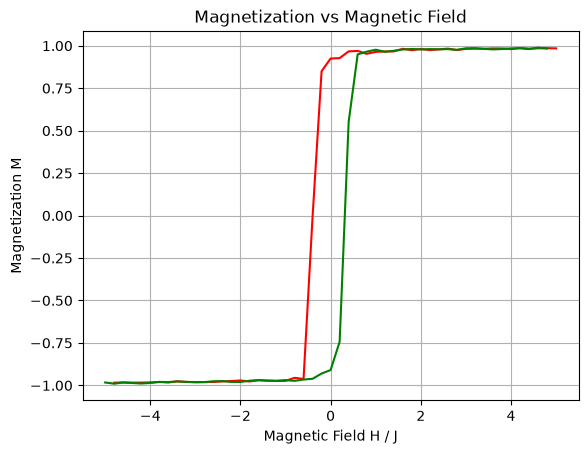

Anisotropy Term: 0.25


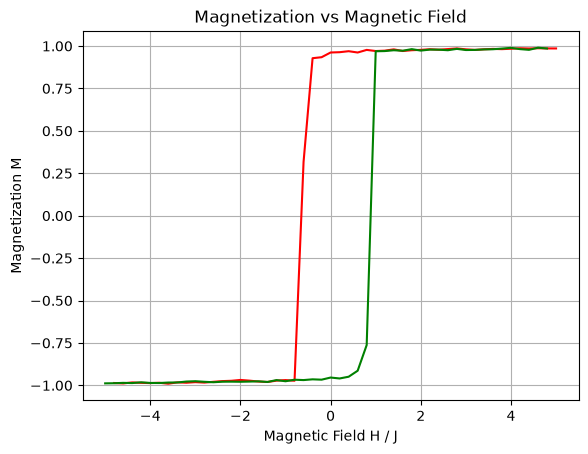

Anisotropy Term: 0.5


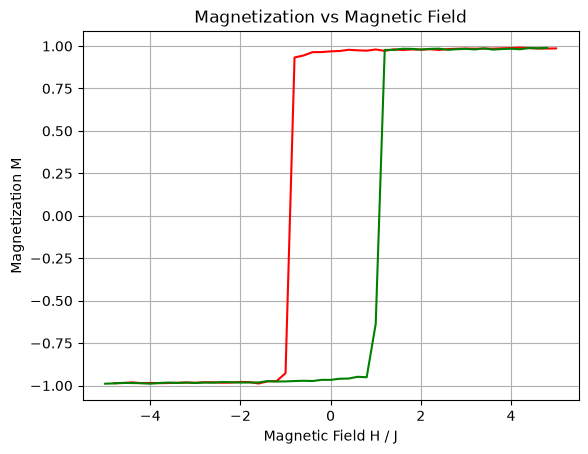

Anisotropy Term: 1


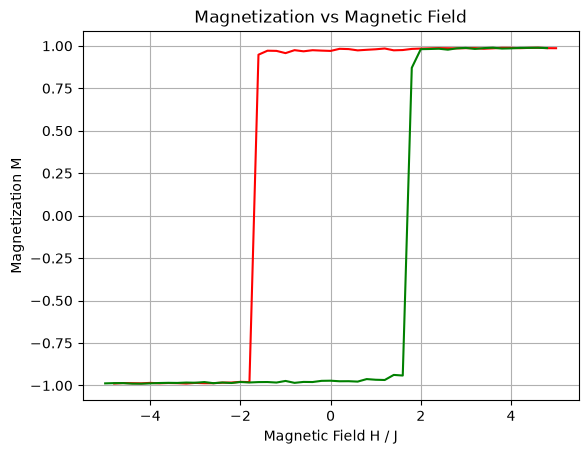

Anisotropy Term: 2


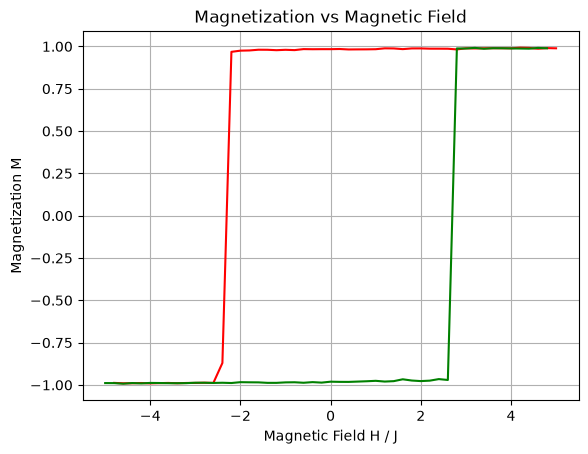

Anisotropy Term: 5


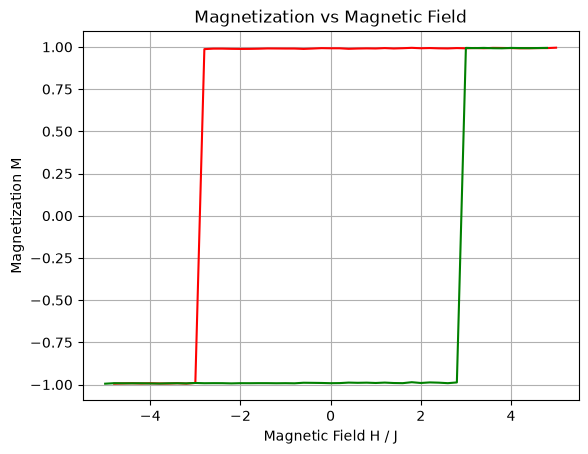

Anisotropy Term: 10


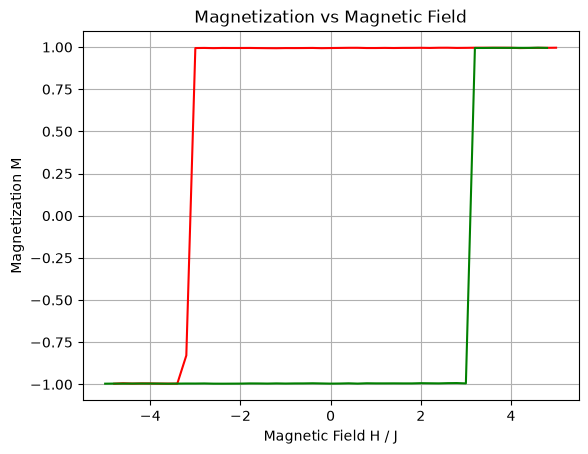

Anisotropy Term: 20


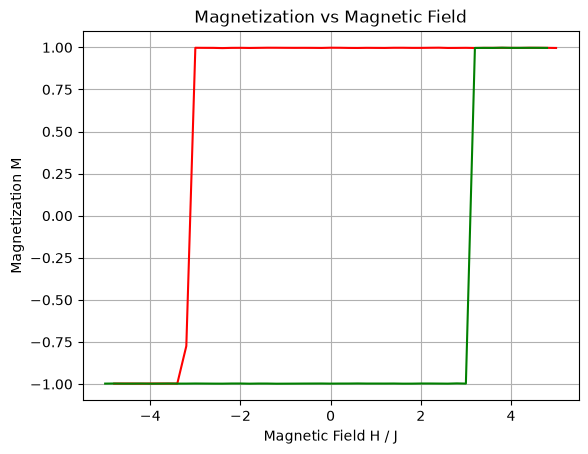

Anisotropy Term: 50


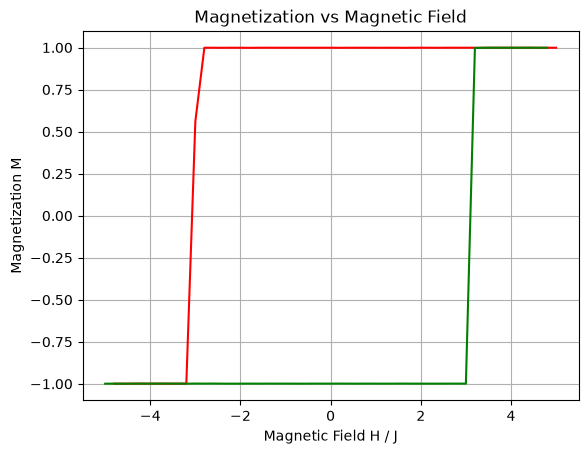

Anisotropy Term: 100


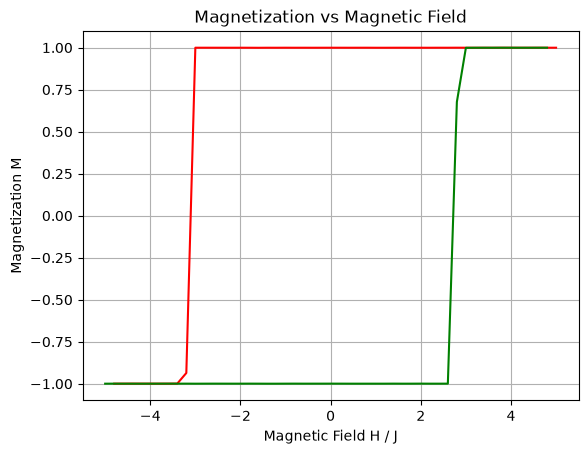

In [20]:
spinsAngle,L = loadData()
J = 1.0
T = 0.25
D = 0
H = 5
dH = 0.2

#Syntax: Hysteresis(J,T,H,dH,spins,L,Sweeps)

Dlist=[0,0.25,0.5,1,2,5,10,20,50,100]
Hc=[]

for D in Dlist:
    print("Anisotropy Term:",D)
    Hc.append(Hysteresis(J,D,T,H,dH,100))
    spinsAngle,L = loadData()

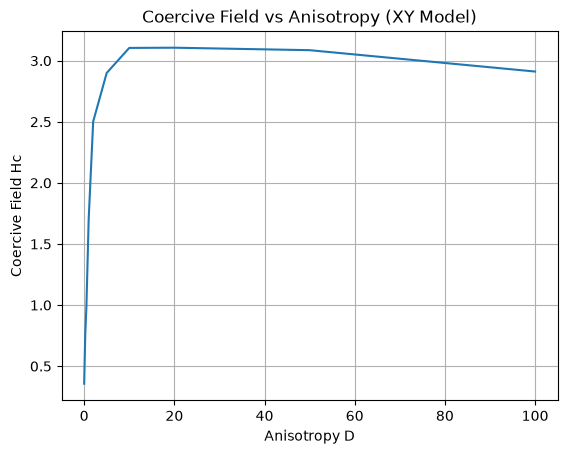

In [26]:
plt.plot(Dlist, Hc)
plt.xlabel("Anisotropy D")
plt.ylabel("Coercive Field Hc")
plt.title("Coercive Field vs Anisotropy (XY Model)")
plt.grid()
plt.show()